Compare the pattern of activity on homings in barrier conditions divided yb whether they end at the barrier or at the shelter
- Is the pattern tuning scaling?
- Make this plot only for sig. tuned cells to %escape

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

# JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# "JAL3_7sept", "JAL3_4sept", "JAL3_1sept", "JAL3_25aug", "JAL3_22aug",

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

In [2]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.escape_utils import load, load_homing, compute_escape_trajectory
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods
from JR_test_scripts.escape.escape_plotting_funcs import plot_tuning_matrix
from JR_test_scripts.escape.escape_tuning_funcs import tuning_method

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore

%matplotlib inline

In [3]:
"""Load data and compute length of each homing"""
exp = experiments_objects[7]

nickname = exp.nick_name + '_' + exp.experiment_date
c_names = ['shelter_only', 'barrier', 'flipped_barrier']

comp = 'escape'

session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
ons, offs, homie = load_homing(session, len(behave))
fcm = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)
var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                fcm, 
                                                                                behave, 
                                                                                y_pos, x_pos, 
                                                                                bar, 
                                                                                barflip, 
                                                                                comp, 
                                                                                ons, offs, 
                                                                                no_stationary = False, 
                                                                                return_escape = True,
                                                                                zscore = False)

X, _, _, _, _ = extract_homing_and_escape_periods(session, 
                                                    fcm, 
                                                    x_pos, 
                                                    y_pos, x_pos, 
                                                    bar, 
                                                    barflip, 
                                                    'speed', 
                                                    ons, offs, 
                                                    no_stationary = False, 
                                                    return_escape = True,
                                                    zscore = False)

Y, _, _, _, _ = extract_homing_and_escape_periods(session, 
                                                    fcm, 
                                                    y_pos, 
                                                    y_pos, x_pos, 
                                                    bar, 
                                                    barflip, 
                                                    'speed', 
                                                    ons, offs, 
                                                    no_stationary = False, 
                                                    return_escape = True,
                                                    zscore = False)

all_homings = np.append(h_start,len(cond))
homing_cum_dist = np.full_like(h_start, np.nan)
for h, _ in enumerate(all_homings[:-1]):
    homing_cum_dist[h] = compute_escape_trajectory(X[all_homings[h]:all_homings[h+1]],Y[all_homings[h]:all_homings[h+1]])[-1]

2025-02-27 15:49:58.170 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\_core\numeric.py:452: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


In [4]:
"""Find the sig. cells!"""
%matplotlib inline
%autoreload 2

# 1. load in explore tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
saving_file = dump_path + exp_nickname + '_Tuning.npz'
data = np.load(saving_file)

# pull out the params
data_files = data.files
exp_params_real = data['params_real']
exp_params_shifts = data['params_shifts']

# 2. load in homing/escape tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

data_files = data.files
fr_real = data['fr_real']
params_real = data['params_real']
params_shifts = data['params_shifts']

# load in residuals data
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ResidualsTuning.npz'
data = np.load(saving_file)
data_files = data.files
params_real_exp = data['params_real_exp']
params_shifts_exp_res = data['params_shifts_exp_res']

# identify cells that are sig tuned to %escape in homing/escape
sig_escape = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)

# identify cells that are sig tuned to distance to shelter in exploration
exp_sig_dist = exp_params_real[:,:,0] > np.nanpercentile(exp_params_shifts[:,:,:,0], 95, axis = 0)

# ifnd cells whose residual tuning to %escape - distance to shelter in exploration is significant
sig_res = params_real_exp[:,:,0] > np.nanpercentile(params_shifts_exp_res[:,:,:,0], 95, axis = 0)

# identify significant cells of interest to create xval matrix of length neurons x conditions
xval = np.full_like(sig_escape, np.nan)
for c in range(3):
    A = (sig_escape[:, c] == True) & (exp_sig_dist[:, c] == False) & (sig_res[:, c] == False)  # V1 only
    AC = (sig_escape[:, c] == True) & (sig_res[:, c] == True)  # Both V1 and V1 regressed
    xval[:,c] = (A == True) | (AC == True)

Text(0, 0.5, 'shelter homings')

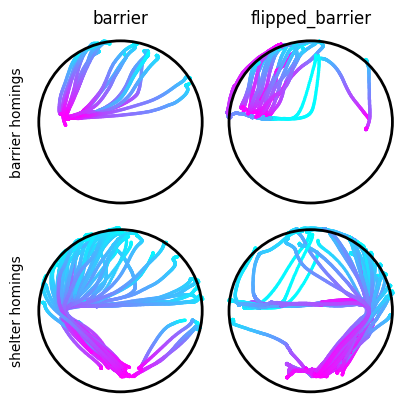

In [16]:
""""Make a plot of the trajectories of short and long homings"""

# Example Data
cutoff = [550]
homies = np.array(h_start)
homies_with_end = np.append(homies, len(cond))
destination = np.full_like(homing_cum_dist, np.nan)
fig, axs = plt.subplots(2, 2, figsize=(4, 4), constrained_layout=True)  # Adjusted size for square subplots

for i, h in enumerate(homies):
    c = int(cond[h])  
    if c == 0:
        continue
    # Get trial data
    x_points = X[h:homies_with_end[i+1]]
    y_points = Y[h:homies_with_end[i+1]]
    destination[i] = y_points[-1]
    num_points = len(x_points)

    # pick the axis based on where the homing ends
    ax = axs[0, c-1] if y_points[-1] < cutoff else axs[1, c-1]

    # Create a gradient color transition from blue to purple
    colors = plt.cm.cool(np.linspace(0, 1, num_points))  

    # Scatter plot with gradual color change
    ax.scatter(x_points, y_points, s=2, color=colors)

# Apply settings to all subplots
for ax in axs.flat:
    ax.set_xlim(0, 1024)
    ax.set_ylim(0, 1024)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.invert_yaxis()  # Flip y-axis
    ax.set_frame_on(False)  # Remove border
    circle = plt.Circle((512, 512), 460, color='black', fill=False, linewidth=2)
    ax.add_patch(circle)

for c in [1,2]:
    axs[0,c-1].set_title(c_names[c])

axs[0,0].set_ylabel('barrier homings')
axs[1,0].set_ylabel('shelter homings')

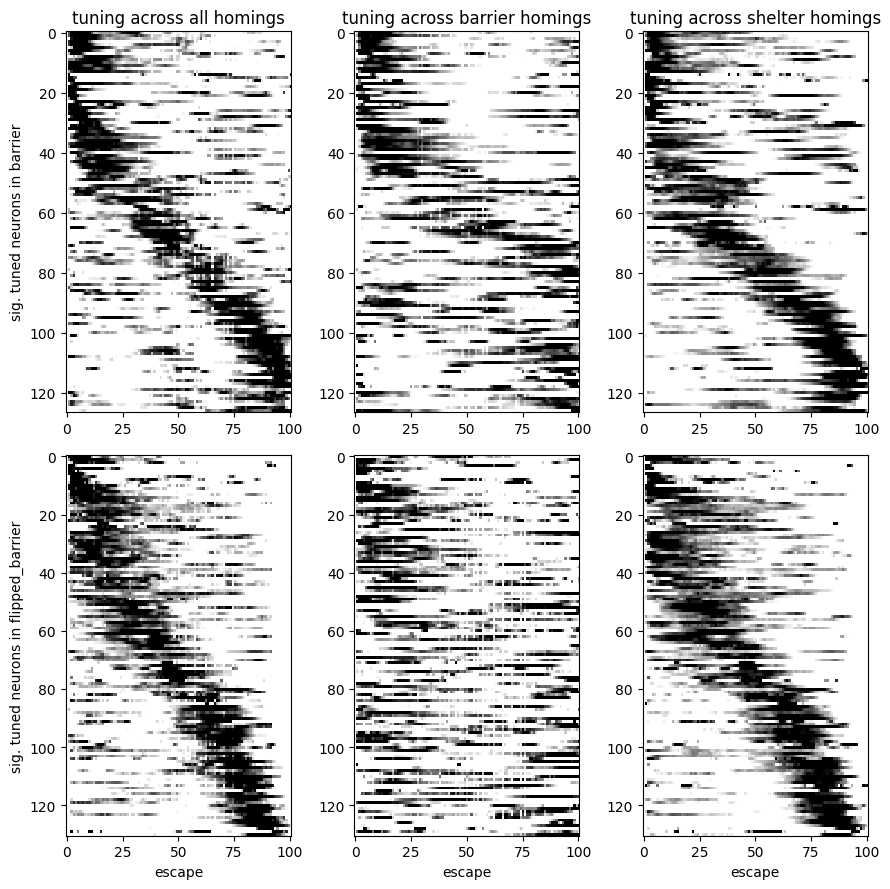

In [13]:
""""Make a plot of the tuning curve + the response on short homings + the response on long homings sorted by tuning curve peak"""

homing_cond = cond[h_start]
homies = np.array(h_start)
homies_with_end = np.append(homies,len(cond))
bins = int(np.amax(var)+1)
n_neur = frame_by_cluster_matrix.shape[1]
n_cond = len(np.unique(cond))

# short homings
short_e_mat = []
short_cond = []
offset = 0
for c in [1,2]:
    # pick the homings in this condition that end at the barrier
    short_homies_this_c = homies[(homing_cond == c) & (destination < cutoff)]
    for h in short_homies_this_c:
        in_list = np.where(homies == h)[0]
        in_list = in_list.item()  
        homing_len = int(homies_with_end[in_list + 1] - h)
        if len(short_e_mat) == 0:
            short_e_mat = escape_matrix[:,h:int(homies_with_end[in_list + 1])]
            short_var = var[h:int(homies_with_end[in_list + 1])]
            short_h_start = offset
        else:
            short_e_mat = np.hstack((short_e_mat, escape_matrix[:,h:int(homies_with_end[in_list + 1])]))
            short_var = np.hstack((short_var, var[h:int(homies_with_end[in_list + 1])]))
            short_h_start = np.append(short_h_start, offset)
        offset += homing_len
    if len(short_cond) == 0:
        short_cond = np.ones(offset)*c
    else:
        short_cond = np.append(short_cond, np.ones(offset - len(short_cond))*c)

# pull out the mean firing per bin of %escape 
_, _, fr_short, _, _ = tuning_method(short_var, 
                                    short_e_mat, 
                                    short_cond, 
                                    short_h_start, 
                                    bins, 
                                    n_cond,
                                    n_neur,
                                    fitting = False)
# plot_tuning_matrix(tuning_matrix, short_cond, comp, zscore(short_e_mat, axis = 1), short_var, esc_start, short_h_start, xval, nickname = exp_nickname + '_ResidualTuning', peak_firing_condition = [], dump_path = "Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname, show = True)

# long homings
long_e_mat = []
long_cond = []
offset = 0
for c in [1,2]:
    # pick the homings in this condition that end at the shelter
    long_homies_this_c = homies[(homing_cond == c) & (destination > cutoff)]
    for h in long_homies_this_c:
        in_list = np.where(homies == h)[0]
        in_list = in_list.item()  
        homing_len = int(homies_with_end[in_list + 1] - h)
        if len(long_e_mat) == 0:
            long_e_mat = escape_matrix[:,h:int(homies_with_end[in_list + 1])]
            long_var = var[h:int(homies_with_end[in_list + 1])]
            long_h_start = offset
        else:
            long_e_mat = np.hstack((long_e_mat, escape_matrix[:,h:int(homies_with_end[in_list + 1])]))
            long_var = np.hstack((long_var, var[h:int(homies_with_end[in_list + 1])]))
            long_h_start = np.append(long_h_start, offset)
        offset += homing_len
    if len(long_cond) == 0:
        long_cond = np.ones(offset)*c
    else:
        long_cond = np.append(long_cond, np.ones(offset - len(long_cond))*c)

_, _, fr_long, _, _ = tuning_method(long_var, 
                                    long_e_mat, 
                                    long_cond, 
                                    long_h_start, 
                                    bins, 
                                    n_cond,
                                    n_neur,
                                    fitting = False)
# plot_tuning_matrix(tuning_matrix, long_cond, comp, zscore(long_e_mat, axis = 1), long_var, esc_start, long_h_start, xval, nickname = exp_nickname + '_ResidualTuning', peak_firing_condition = [], dump_path = "Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname, show = True)

"""Make the plot!"""
peak_firing_condition = params_real[:,:,1]
fig, axs = plt.subplots(2,3,figsize = (9,9))
for c in [1,2]:
    good_n = xval[:,c] == True
    good_real = fr_real[c,good_n,:]
    good_peaks = peak_firing_condition[good_n,:]
    sorter = np.argsort(good_peaks[:,c])
    axs[c-1,0].imshow(zscore(good_real[sorter,:], axis = 1), cmap="gray_r", vmin=0, vmax=1.2, aspect="auto", interpolation="none")
    good_short = fr_short[c,good_n,:]
    axs[c-1,1].imshow(zscore(good_short[sorter,:], axis = 1), cmap="gray_r", vmin=0, vmax=1.2, aspect="auto", interpolation="none")
    good_long = fr_long[c,good_n,:]
    axs[c-1,2].imshow(zscore(good_long[sorter,:], axis = 1), cmap="gray_r", vmin=0, vmax=1.2, aspect="auto", interpolation="none")
    axs[c-1,0].set_ylabel('sig. tuned neurons in ' + c_names[c])
axs[0,0].set_title('tuning across all homings')
axs[0,1].set_title('tuning across barrier homings')
axs[0,2].set_title('tuning across shelter homings')
for i in [0,1,2]: axs[1,i].set_xlabel(comp)
plt.tight_layout()